# Gaussian Process model of the unbalanced disk

The goal of this notebook is to identify the dynamics of the unbalanced disk from measured input-output data. The input is the motor voltage $u_k$ and the output is the measured disk angle $\theta_k$. Angular velocity is not used.

A GP-NARX model is used because the next angle depends on previous angles and previous voltage inputs. The workflow is:

1. inspect and split the measured data;
2. construct the NARX regressors;
3. compare the GP with simple baseline models;
4. study the lag order and kernel choice;
5. train a sparse GP on the full training set;
6. evaluate one-step prediction and free-run simulation;
7. evaluate the selected model on held-out test data;
8. summarize the final performance and generate the submission files.

The model choices are made using the validation set. The test portion is kept separate during model development.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
# Load dataset
data  = np.genfromtxt('training-val-test-data.csv', delimiter=',', skip_header=1)
u_all  = data[:, 0]   # input voltage [V]
th_all = data[:, 1]   # disk angle [rad]

N = len(u_all)
print(f"Samples: {N}")
print(f"u  — min: {u_all.min():.3f} V,  max: {u_all.max():.3f} V")
print(f"θ  — min: {np.degrees(th_all.min()):.1f}°,  max: {np.degrees(th_all.max()):.1f}°,  std: {np.degrees(th_all.std()):.1f}°")

Samples: 35000
u  — min: -3.103 V,  max: 3.337 V
θ  — min: -108.9°,  max: 124.9°,  std: 27.5°


In [30]:
# We create contiguous sets to avoid data leakage
split_train = int(0.70 * N) 
split_val   = int(0.85 * N)  

u_train,  th_train  = u_all[:split_train],          th_all[:split_train]
u_val,    th_val    = u_all[split_train:split_val],  th_all[split_train:split_val]
u_test,   th_test   = u_all[split_val:],             th_all[split_val:]

print(f"Training  : {len(u_train):>6} samples")
print(f"Validation: {len(u_val):>6} samples")
print(f"Test      : {len(u_test):>6} samples")

Training  :  24500 samples
Validation:   5250 samples
Test      :   5250 samples


## 1. Data inspection

The data is split chronologically into training, validation, and test sets. Neighboring samples in a dynamic experiment are strongly related, so a random split could leak information from the future into the training set.

### Time-domain signals

The voltage and angle sequences are plotted first. This gives an overview of the operating range, the excitation of the system, and possible differences between the data sections.

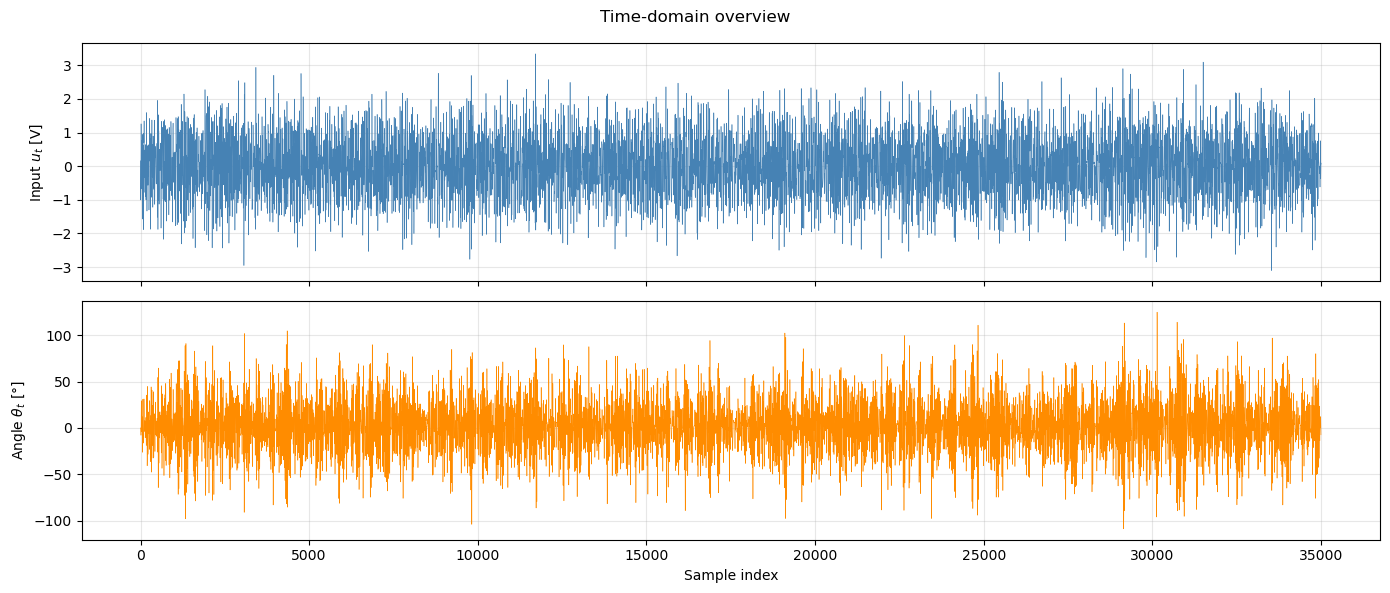

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(u_all, lw=0.4, color='steelblue')
axes[0].set_ylabel("Input $u_t$ [V]") 
axes[0].grid(alpha=0.3)
axes[1].plot(np.degrees(th_all), lw=0.4, color='darkorange')
axes[1].set_ylabel("Angle $\\theta_t$ [°]"); 
axes[1].set_xlabel("Sample index")
axes[1].grid(alpha=0.3)
plt.suptitle("Time-domain overview", fontsize=12)
plt.tight_layout(); plt.show()

### Distribution of the measured angle

The histogram shows which angles occur most often in the training data. A GP is generally more reliable in regions that are well represented by training samples.

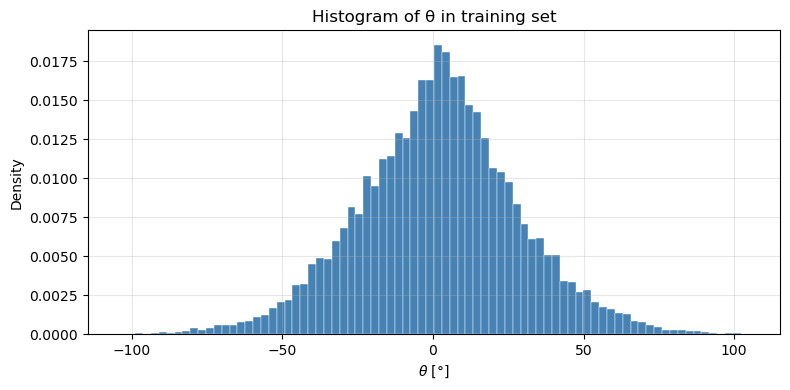

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(np.degrees(th_train), bins=80, density=True,
        color='steelblue', edgecolor='white', linewidth=0.3)

ax.set_xlabel("$\\theta$ [°]"); ax.set_ylabel("Density")
ax.set_title("Histogram of θ in training set")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Initial estimate of the measurement noise

An approximate noise level is obtained from angle differences during low-input periods. If the physical angle is nearly constant, differencing two noisy measurements gives a variance of approximately $2\sigma_e^2$.

This is only an initial estimate. A small voltage does not guarantee that the disk is fully stationary, so the GP is still allowed to optimize its noise variance later.

In [33]:
# Variance of Δθ on Near-static segments ≈ 2σ_e²  (differencing doubles the noise variance)
static_mask = np.abs(u_train[1:]) < 0.1
dth_static  = np.diff(th_train)[static_mask]

sigma_e_est  = np.std(dth_static) / np.sqrt(2)
sigma_e2_est = sigma_e_est ** 2

print(f"Near-static samples used: {static_mask.sum()}")
print(f"Estimated σ_e  ≈ {sigma_e_est:.5f} rad  ({np.degrees(sigma_e_est):.3f}°)")
print(f"Estimated σ_e² ≈ {sigma_e2_est:.6f} rad²")

Near-static samples used: 2306
Estimated σ_e  ≈ 0.08291 rad  (4.750°)
Estimated σ_e² ≈ 0.006874 rad²


## 2. NARX model structure

The GP input contains previous angles and previous voltage inputs:

$$x_k=[\theta_{k-n_a},\ldots,\theta_{k-1},u_{k-n_b},\ldots,u_{k-1}].$$

The first target is the current angle $\theta_k$. The orders $n_a$ and $n_b$ determine how much past information is available. The initial choice is $n_a=4$ angle lags and $n_b=2$ input lags; the angle order is examined later.

In [34]:
def make_training_data(u, th, na, nb):
    X, Y = [], []
    for k in range(max(na, nb), len(u)):
        th_feat = [th[k-na+i] for i in range(na)]
        u_feat = [u[k-nb+i] for i in range(nb)]
        X.append(th_feat + u_feat)
        Y.append(th[k])
    return np.array(X), np.array(Y)

na, nb = 4, 2

Xtrain, Ytrain = make_training_data(u_train, th_train, na, nb)
Xval,   Yval   = make_training_data(u_val,   th_val,   na, nb)

print(f"Xtrain shape: {Xtrain.shape}")
print(f"Xval shape: {Xval.shape}")
print(f"Ytrain shape {Ytrain.shape}")
print(f"Ytrain shape {Yval.shape}")

Xtrain shape: (24496, 6)
Xval shape: (5246, 6)
Ytrain shape (24496,)
Ytrain shape (5246,)


### Feature scaling

Angle and voltage have different units and numerical ranges. Standardization gives every feature zero mean and unit variance based on the training data. This improves numerical conditioning and makes the GP length scales easier to optimize.

The validation data is transformed with the training-set scalers, so no validation information is used during fitting. Scaling is used for the exact-GP screening models. The final GPy sparse model is trained in physical units so that its periodic angle kernel keeps a direct interpretation in radians.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

Xtrain_s = scaler_x.fit_transform(Xtrain)
Ytrain_s = scaler_y.fit_transform(Ytrain.reshape(-1,1))

Xval_s = scaler_x.transform(Xval)
Yval_s = scaler_y.transform(Yval.reshape(-1,1))

### Evaluation measures

Two measures are used throughout the notebook:

- **RMSE** gives the typical error in radians or degrees.
- **Best Fit Rate (BFR)** compares the model error with the variation in the measured output. A larger BFR indicates a better fit.

Both one-step prediction and free-run simulation are evaluated. Prediction uses measured past angles. Simulation feeds previous model outputs back into the model and is therefore the stricter test.

In [36]:
# Best Fit Rate (BFR) metric

def BFR(y_true, y_pred):
    num = np.sqrt(np.sum((y_true - y_pred)**2))
    den = np.sqrt(np.sum((y_true - np.mean(y_true))**2))
    return 100 * max(1 - num/den, 0)

def RMSE(ytrue, ypred):
    return np.sqrt(np.mean((ytrue-ypred)**2))

In [37]:
print("Xtrain_s stats (should be ~mean=0, std=1):")
print(f"  mean: {Xtrain_s.mean(axis=0).round(3)}")
print(f"  std:  {Xtrain_s.std(axis=0).round(3)}")

print("\nYtrain_s stats:")
print(f"  mean: {Ytrain_s.mean():.3f}  (should be ~0)")
print(f"  std:  {Ytrain_s.std():.3f}   (should be ~1)")

print("\nXval_s stats (should be close to 0 mean, ~1 std):")
print(f"  mean: {Xval_s.mean(axis=0).round(3)}")
print(f"  std:  {Xval_s.std(axis=0).round(3)}")

Xtrain_s stats (should be ~mean=0, std=1):
  mean: [ 0.  0.  0.  0.  0. -0.]
  std:  [1. 1. 1. 1. 1. 1.]

Ytrain_s stats:
  mean: 0.000  (should be ~0)
  std:  1.000   (should be ~1)

Xval_s stats (should be close to 0 mean, ~1 std):
  mean: [-0.004 -0.004 -0.004 -0.004  0.001  0.   ]
  std:  [1.052 1.052 1.052 1.052 1.012 1.012]


## 3. Comparison with simple baseline models

The measured angle changes smoothly, so a high one-step prediction score can be obtained without learning the full nonlinear dynamics. To put the GP result into perspective, it is first compared with two simpler models:

- **Persistence:** $\hat{\theta}_k=\theta_{k-1}$.
- **Linear ARX:** a linear model using the same angle and input lags.
- **GP-NARX:** a nonlinear GP model that predicts $\theta_k$ directly.

Persistence measures how much performance is obtained by copying the latest angle. The linear ARX model then shows whether a linear dynamic relation is sufficient. The GP is useful only if its nonlinear flexibility gives a meaningful improvement over these references. All three models use the same lag orders and validation data.

Exact GP training becomes expensive as the number of samples increases because its computational cost grows approximately as $\mathcal{O}(N^3)$. A fixed random subset of 1000 training samples is therefore used for this preliminary comparison. The complete training set is used later with a sparse GP.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# Fixed random subset because an exact GP is too expensive on all training samples.
N_GP_BASELINE = min(1000, len(Xtrain))
rng_gp = np.random.default_rng(42)
gp_subset_idx = np.sort(rng_gp.choice(len(Xtrain), N_GP_BASELINE, replace=False))

# Linear ARX reference using the normalized regressors from Section 2.
linear_arx = LinearRegression()
linear_arx.fit(Xtrain_s, Ytrain)

# Smooth GP model with a white-noise term.
direct_kernel = RBF(length_scale=0.5) + WhiteKernel(noise_level=1e-3)
gp_direct = GaussianProcessRegressor(
    kernel=direct_kernel,
    n_restarts_optimizer=3,
    random_state=42,
)
gp_direct.fit(
    Xtrain_s[gp_subset_idx],
    Ytrain_s[gp_subset_idx].ravel(),
)

print(f"GP training samples: {N_GP_BASELINE}")
print("Optimized direct-GP kernel:", gp_direct.kernel_)

GP training samples: 1000
Optimized direct-GP kernel: RBF(length_scale=4.2) + WhiteKernel(noise_level=5.34e-05)


In [39]:
# One-step-ahead predictions for the three baseline models.
pred_persistence = Xval[:, na - 1].copy()  # final angle feature is theta(k-1)
pred_linear = linear_arx.predict(Xval_s)

pred_direct_s, std_direct_s = gp_direct.predict(Xval_s, return_std=True)
pred_direct = scaler_y.inverse_transform(pred_direct_s[:, None]).ravel()
std_direct = std_direct_s * scaler_y.scale_[0]

prediction_baseline_results = {
    "Persistence": {
        "BFR [%]": BFR(Yval, pred_persistence),
        "RMSE [rad]": RMSE(Yval, pred_persistence),
    },
    "Linear ARX": {
        "BFR [%]": BFR(Yval, pred_linear),
        "RMSE [rad]": RMSE(Yval, pred_linear),
    },
    "Direct GP-NARX": {
        "BFR [%]": BFR(Yval, pred_direct),
        "RMSE [rad]": RMSE(Yval, pred_direct),
    },
}

print("One-step-ahead validation results")
print(f"{'Model':<20} {'BFR [%]':>10} {'RMSE [rad]':>12} {'RMSE [deg]':>12}")
for model_name, values in prediction_baseline_results.items():
    print(
        f"{model_name:<20} {values['BFR [%]']:>10.2f} "
        f"{values['RMSE [rad]']:>12.5f} "
        f"{np.degrees(values['RMSE [rad]']):>12.3f}"
    )

One-step-ahead validation results
Model                   BFR [%]   RMSE [rad]   RMSE [deg]
Persistence               73.86      0.12865        7.371
Linear ARX                98.94      0.00521        0.299
Direct GP-NARX            98.66      0.00659        0.378


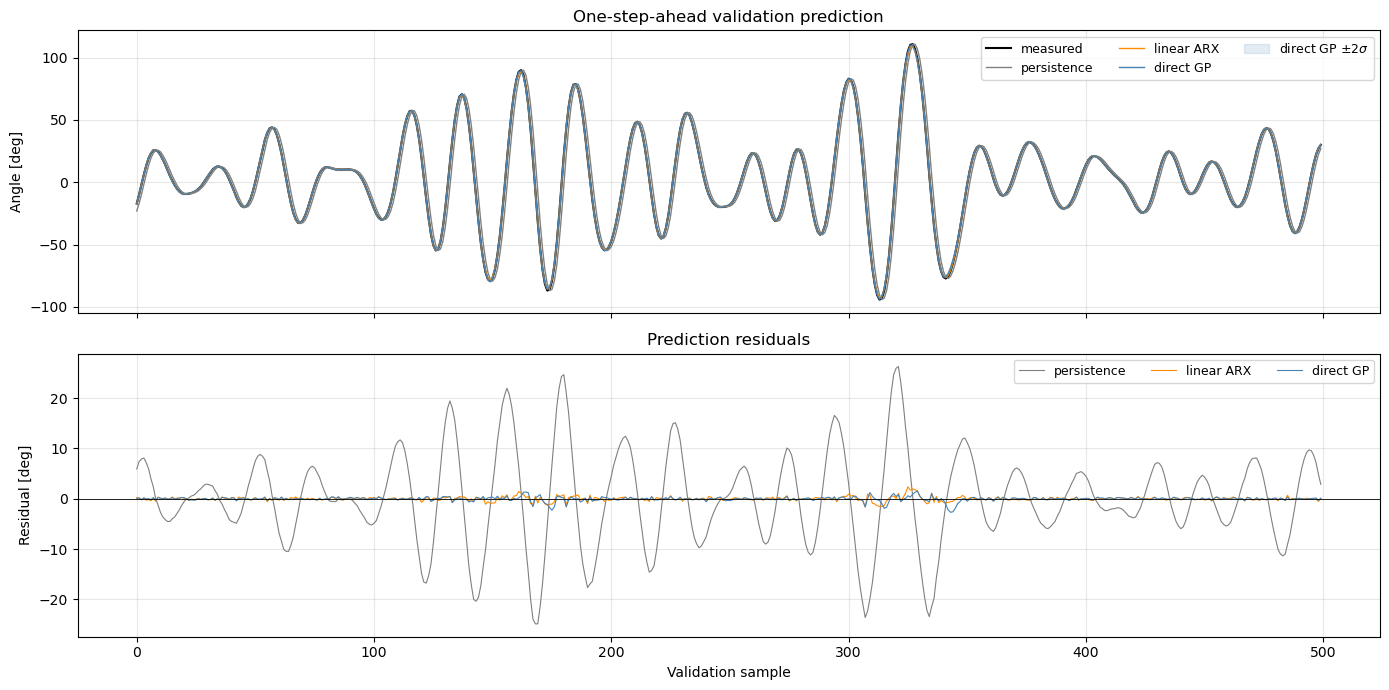

In [40]:
# A short interval keeps the differences and residuals readable.
N_COMPARE_PLOT = min(500, len(Yval))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(np.degrees(Yval[:N_COMPARE_PLOT]), 'k', lw=1.5, label='measured')
axes[0].plot(np.degrees(pred_persistence[:N_COMPARE_PLOT]), color='gray', lw=1, label='persistence')
axes[0].plot(np.degrees(pred_linear[:N_COMPARE_PLOT]), color='darkorange', lw=1, label='linear ARX')
axes[0].plot(np.degrees(pred_direct[:N_COMPARE_PLOT]), color='steelblue', lw=1, label='direct GP')
axes[0].fill_between(
    np.arange(N_COMPARE_PLOT),
    np.degrees(pred_direct[:N_COMPARE_PLOT] - 2 * std_direct[:N_COMPARE_PLOT]),
    np.degrees(pred_direct[:N_COMPARE_PLOT] + 2 * std_direct[:N_COMPARE_PLOT]),
    color='steelblue', alpha=0.15, label='direct GP $\\pm2\\sigma$'
)
axes[0].set_ylabel("Angle [deg]")
axes[0].set_title("One-step-ahead validation prediction")
axes[0].legend(ncol=3, fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(np.degrees(Yval[:N_COMPARE_PLOT] - pred_persistence[:N_COMPARE_PLOT]), color='gray', lw=0.8, label='persistence')
axes[1].plot(np.degrees(Yval[:N_COMPARE_PLOT] - pred_linear[:N_COMPARE_PLOT]), color='darkorange', lw=0.8, label='linear ARX')
axes[1].plot(np.degrees(Yval[:N_COMPARE_PLOT] - pred_direct[:N_COMPARE_PLOT]), color='steelblue', lw=0.8, label='direct GP')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel("Validation sample")
axes[1].set_ylabel("Residual [deg]")
axes[1].set_title("Prediction residuals")
axes[1].legend(ncol=3, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion.** The linear ARX model gives the best one-step reference result, with a BFR of **98.94%** and an RMSE of **0.299°**. The GP trained on 1000 samples reaches **98.66%** BFR and **0.378°** RMSE. This small difference shows that the local one-step relation is largely captured by a linear model. The lower persistence score of **73.86%** confirms that the result cannot be explained by simply copying the previous angle.

## 4. Model structure and kernel selection

The lag orders and kernel structure are selected before the final sparse model is trained. Exact GPs on smaller subsets are used for these comparisons so that several alternatives can be evaluated with the same validation data.

### 4.1 Selection of the NARX lag orders

The lag orders determine how much dynamic history is available to the model. If the orders are too small, relevant past behavior may be missing. If they are too large, the regressor contains unnecessary variables and the GP becomes more expensive to train.

Several small values of $n_a$ and $n_b$ are compared using the same RBF + White kernel. A reduced training subset keeps this screening step practical. The heatmap identifies the point where adding more lags gives little further improvement. The final decision also considers model complexity and free-run simulation performance.

In [41]:
na_candidates = [1, 2, 3, 4, 5, 6]
nb_candidates = [1, 2, 3]
lag_bfr = np.zeros((len(na_candidates), len(nb_candidates)))

# Small subsets keep the exact-GP order screening practical.
N_LAG_TRAIN = 500
N_LAG_VAL = 500

for i, na_try in enumerate(na_candidates):
    for j, nb_try in enumerate(nb_candidates):
        X_lag, Y_lag = make_training_data(u_train, th_train, na_try, nb_try)
        X_lag_val, Y_lag_val = make_training_data(u_val, th_val, na_try, nb_try)

        idx_lag = np.linspace(0, len(X_lag) - 1, N_LAG_TRAIN, dtype=int)
        idx_lag_val = np.linspace(0, len(X_lag_val) - 1, N_LAG_VAL, dtype=int)

        lag_scaler_x = StandardScaler().fit(X_lag[idx_lag])
        lag_scaler_y = StandardScaler().fit(Y_lag[idx_lag, None])
        X_lag_s = lag_scaler_x.transform(X_lag[idx_lag])
        Y_lag_s = lag_scaler_y.transform(Y_lag[idx_lag, None]).ravel()
        X_lag_val_s = lag_scaler_x.transform(X_lag_val[idx_lag_val])

        lag_kernel = RBF(length_scale=0.5) + WhiteKernel(noise_level=1e-3)
        lag_model = GaussianProcessRegressor(
            lag_kernel, n_restarts_optimizer=0, random_state=42
        )
        lag_model.fit(X_lag_s, Y_lag_s)

        pred_lag_s = lag_model.predict(X_lag_val_s)
        pred_lag = lag_scaler_y.inverse_transform(pred_lag_s[:, None]).ravel()
        lag_bfr[i, j] = BFR(Y_lag_val[idx_lag_val], pred_lag)
        print(f"na={na_try}, nb={nb_try}: BFR={lag_bfr[i, j]:.2f}%")

best_lag_index = np.unravel_index(np.argmax(lag_bfr), lag_bfr.shape)
best_na_screen = na_candidates[best_lag_index[0]]
best_nb_screen = nb_candidates[best_lag_index[1]]
print(f"\nBest order in this screening: na={best_na_screen}, nb={best_nb_screen}")
print(f"Order retained for the final model: na={na}, nb={nb}")

 /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning:The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
 /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning:The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.


na=1, nb=1: BFR=0.00%


 /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning:The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.


na=1, nb=2: BFR=0.00%
na=1, nb=3: BFR=75.88%
na=2, nb=1: BFR=97.63%
na=2, nb=2: BFR=98.22%
na=2, nb=3: BFR=98.16%
na=3, nb=1: BFR=97.85%
na=3, nb=2: BFR=98.59%
na=3, nb=3: BFR=98.53%
na=4, nb=1: BFR=98.13%
na=4, nb=2: BFR=98.60%


 /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning:lbfgs failed to converge after 9 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


na=4, nb=3: BFR=98.60%
na=5, nb=1: BFR=98.32%
na=5, nb=2: BFR=98.50%
na=5, nb=3: BFR=98.55%
na=6, nb=1: BFR=98.12%
na=6, nb=2: BFR=98.36%
na=6, nb=3: BFR=98.35%

Best order in this screening: na=4, nb=2
Order retained for the final model: na=4, nb=2


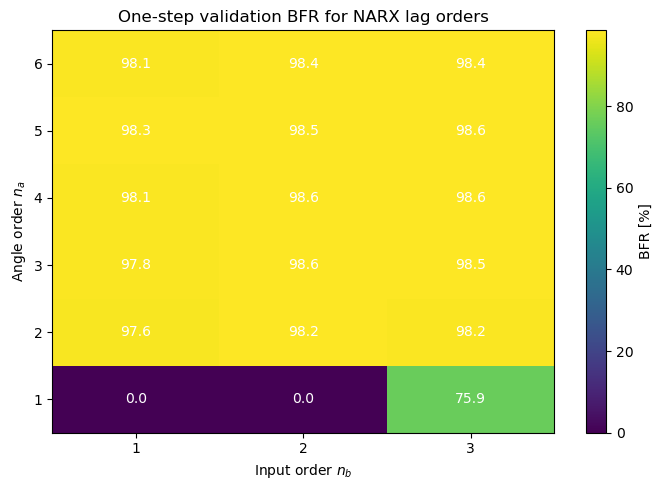

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(lag_bfr, origin='lower', aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(len(nb_candidates)), nb_candidates)
ax.set_yticks(np.arange(len(na_candidates)), na_candidates)
ax.set_xlabel("Input order $n_b$")
ax.set_ylabel("Angle order $n_a$")
ax.set_title("One-step validation BFR for NARX lag orders")

for i in range(len(na_candidates)):
    for j in range(len(nb_candidates)):
        ax.text(j, i, f"{lag_bfr[i, j]:.1f}", ha='center', va='center', color='white')

plt.colorbar(im, ax=ax, label="BFR [%]")
plt.tight_layout()
plt.show()

**Conclusion.** The highest screening score is obtained for $n_a=4$ and $n_b=2$, with a validation BFR of **98.60%**. Nearby orders give almost identical results, indicating a performance plateau. The order $n_a=4$, $n_b=2$ is therefore retained because it achieves the best score without adding unnecessary regressors.

### 4.2 Kernel and hyperparameter comparison

The kernel defines the type of nonlinear functions that the GP can represent. Two structures are compared using the same data, lag orders, scaling, and optimization settings:

- **RBF + White:** assumes a smooth nonlinear relation and includes measurement noise;
- **Matérn + White:** allows a less smooth relation than the RBF kernel.

The white-noise term is included in every model so that the comparison focuses on the covariance structure of the underlying dynamics. Both one-step prediction and free-run simulation are evaluated, since a kernel that performs well locally may still be inaccurate when its predictions are fed back.

The optimized hyperparameters are also inspected. The length scale indicates how rapidly the learned relation can change, the noise level represents unexplained measurement variation, and the periodicity indicates the repeating scale preferred by the model.

In [43]:
from sklearn.gaussian_process.kernels import Matern
import time

N_KERNEL_TRAIN = min(800, len(Xtrain_s))
N_KERNEL_VAL = min(1000, len(Xval_s))
N_KERNEL_SIM = min(1500, len(u_val))
kernel_train_idx = np.linspace(0, len(Xtrain_s) - 1, N_KERNEL_TRAIN, dtype=int)

kernel_candidates = {
    "RBF + White": RBF(length_scale=0.5) + WhiteKernel(noise_level=1e-3),
    "Matern + White": Matern(length_scale=0.5, nu=1.5) + WhiteKernel(noise_level=1e-3),
}

kernel_models = {}
kernel_results = {}

def simulate_sklearn_gp(model, u, th_init, na, nb, n_steps):
    start = max(na, nb)
    y_sim = th_init[:start].astype(float).tolist()
    for k in range(start, n_steps):
        x_raw = np.array(y_sim[k-na:k] + u[k-nb:k].tolist())[None, :]
        x_scaled = scaler_x.transform(x_raw)
        y_scaled = model.predict(x_scaled)[0]
        y_next = scaler_y.inverse_transform([[y_scaled]])[0, 0]
        y_sim.append(float(y_next))
    return np.asarray(y_sim)

for kernel_name, kernel_initial in kernel_candidates.items():
    model_kernel = GaussianProcessRegressor(
        kernel=kernel_initial,
        n_restarts_optimizer=2,
        random_state=42,
    )
    t0 = time.time()
    model_kernel.fit(
        Xtrain_s[kernel_train_idx],
        Ytrain_s[kernel_train_idx].ravel(),
    )
    train_time = time.time() - t0

    pred_kernel_s = model_kernel.predict(Xval_s[:N_KERNEL_VAL])
    pred_kernel = scaler_y.inverse_transform(pred_kernel_s[:, None]).ravel()
    prediction_bfr = BFR(Yval[:N_KERNEL_VAL], pred_kernel)

    sim_kernel = simulate_sklearn_gp(
        model_kernel, u_val, th_val, na, nb, N_KERNEL_SIM
    )
    start_kernel = max(na, nb)
    simulation_bfr = BFR(
        th_val[start_kernel:N_KERNEL_SIM], sim_kernel[start_kernel:]
    )

    kernel_models[kernel_name] = model_kernel
    kernel_results[kernel_name] = {
        "Prediction BFR [%]": prediction_bfr,
        "Simulation BFR [%]": simulation_bfr,
        "Training time [s]": train_time,
        "Initial kernel": str(kernel_initial),
        "Optimized kernel": str(model_kernel.kernel_),
    }

print(f"{'Kernel':<27} {'Pred. BFR':>10} {'Sim. BFR':>10} {'Time [s]':>10}")
for kernel_name, result in kernel_results.items():
    print(
        f"{kernel_name:<27} {result['Prediction BFR [%]']:>10.2f} "
        f"{result['Simulation BFR [%]']:>10.2f} "
        f"{result['Training time [s]']:>10.2f}"
    )

best_kernel_name = max(
    kernel_results, key=lambda name: kernel_results[name]["Simulation BFR [%]"]
)
print(f"\nBest kernel in this preliminary comparison: {best_kernel_name}")

 /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning:lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


Kernel                       Pred. BFR   Sim. BFR   Time [s]
RBF + White                      98.83      80.59       2.88
Matern + White                   98.51      75.81       2.15

Best kernel in this preliminary comparison: RBF + White


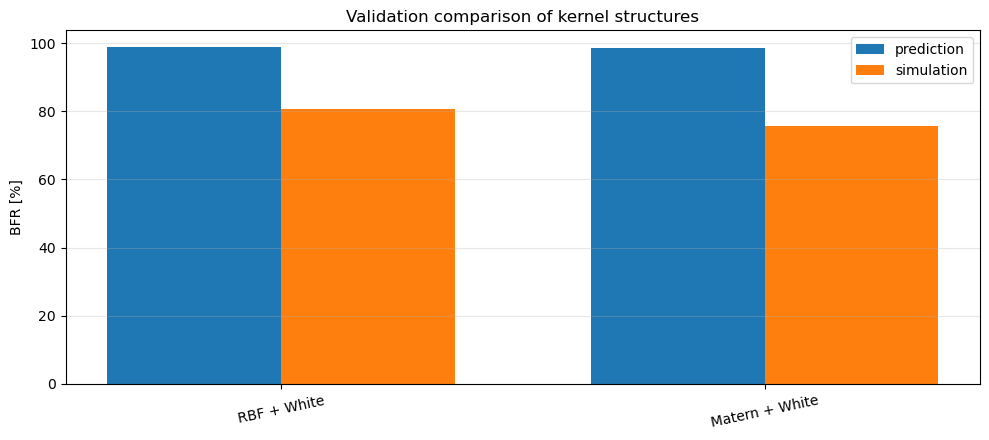

Initial and optimized hyperparameters

RBF + White
  Initial:   RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001)
  Optimized: RBF(length_scale=4.72) + WhiteKernel(noise_level=4.91e-05)

Matern + White
  Initial:   Matern(length_scale=0.5, nu=1.5) + WhiteKernel(noise_level=0.001)
  Optimized: Matern(length_scale=17, nu=1.5) + WhiteKernel(noise_level=2.4e-05)


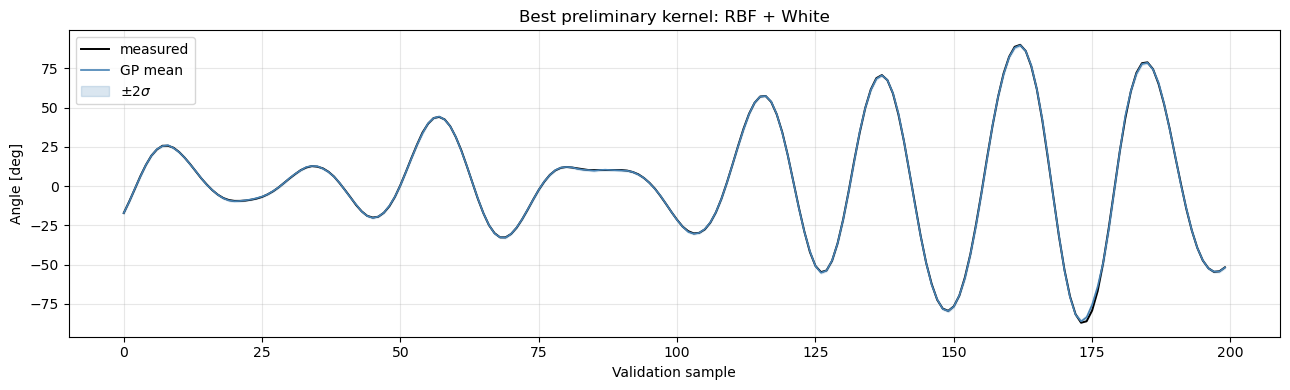

In [44]:
kernel_names = list(kernel_results)
prediction_scores = [kernel_results[name]["Prediction BFR [%]"] for name in kernel_names]
simulation_scores = [kernel_results[name]["Simulation BFR [%]"] for name in kernel_names]

x_kernel = np.arange(len(kernel_names))
width_kernel = 0.36
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x_kernel - width_kernel/2, prediction_scores, width_kernel, label='prediction')
ax.bar(x_kernel + width_kernel/2, simulation_scores, width_kernel, label='simulation')
ax.set_xticks(x_kernel, kernel_names, rotation=12)
ax.set_ylabel("BFR [%]")
ax.set_title("Validation comparison of kernel structures")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Initial and optimized hyperparameters")
for kernel_name, result in kernel_results.items():
    print(f"\n{kernel_name}")
    print("  Initial:  ", result["Initial kernel"])
    print("  Optimized:", result["Optimized kernel"])

# Uncertainty plot for the best preliminary kernel.
best_kernel_model = kernel_models[best_kernel_name]
N_BEST_KERNEL_PLOT = 200
best_pred_s, best_std_s = best_kernel_model.predict(
    Xval_s[:N_BEST_KERNEL_PLOT], return_std=True
)
best_pred = scaler_y.inverse_transform(best_pred_s[:, None]).ravel()
best_std = best_std_s * scaler_y.scale_[0]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.degrees(Yval[:N_BEST_KERNEL_PLOT]), 'k', lw=1.4, label='measured')
ax.plot(np.degrees(best_pred), color='steelblue', lw=1.2, label='GP mean')
ax.fill_between(
    np.arange(N_BEST_KERNEL_PLOT),
    np.degrees(best_pred - 2 * best_std),
    np.degrees(best_pred + 2 * best_std),
    color='steelblue', alpha=0.2, label='$\\pm2\\sigma$'
)
ax.set_xlabel("Validation sample")
ax.set_ylabel("Angle [deg]")
ax.set_title(f"Best preliminary kernel: {best_kernel_name}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_kernel_result = kernel_results[best_kernel_name]

**Conclusion.** The RBF + White kernel performs better than the Matérn + White kernel in both tasks. It reaches **98.83%** prediction BFR and **80.59%** simulation BFR, compared with **98.51%** and **75.81%** for the Matérn model. The optimized RBF length scale is **4.72**, while the optimized noise variance is approximately $4.91\times10^{-5}$. The RBF structure is therefore used as the smooth component of the final sparse model.

## 5. Sparse GP and inducing-point selection

The preliminary studies use exact GPs on subsets of the data. Training an exact GP on the complete dataset is not practical, so a sparse approximation is used for the final model. The sparse GP represents the data through a smaller set of inducing points while retaining a probabilistic prediction.

The model uses the VFE/VarDTC approximation. The number of inducing points controls the balance between accuracy and computation: too few points can underfit the dynamics, while more points increase training time. The best-performing model obtained during development uses $M=200$ inducing points and is retained as the final model.

The kernel treats angle and voltage features separately. The angle component combines periodic and smooth behavior, reflecting the repeating geometry of the disk while allowing local variations. The voltage component uses an RBF kernel because the motor input is not periodic. The kernel parameters and inducing-point locations are optimized using the training data.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import GPy
import time
from GPy.inference.latent_function_inference import VarDTC

def make_sparse_kernel(na, nb):
    kernel_theta = GPy.kern.StdPeriodic(
        input_dim=na,
        active_dims=list(range(na)),
        period=2 * np.pi,
    )
    kernel_theta_smooth = GPy.kern.RBF(
        input_dim=na,
        active_dims=list(range(na)),
        ARD=True,
    )
    kernel_u = GPy.kern.RBF(
        input_dim=nb,
        active_dims=list(range(na, na + nb)),
    )
    return kernel_theta * kernel_theta_smooth + kernel_u

# Keep the best-performing final model at M=200.
M = 200
kernel = make_sparse_kernel(na, nb)
rng_sparse = np.random.default_rng(42)
idx = rng_sparse.choice(len(Xtrain), M, replace=False)
Z = Xtrain[idx].copy()

m_sparse = GPy.models.SparseGPRegression(
    Xtrain, Ytrain.reshape(-1, 1), Z=Z, kernel=kernel
)
m_sparse.inference_method = VarDTC()
m_sparse.likelihood.variance = sigma_e2_est
m_sparse.Z.unconstrain()
t_sparse_final = time.time()
m_sparse.optimize('bfgs', messages=True)
final_sparse_train_time = time.time() - t_sparse_final

print(f"Final sparse-GP training time: {final_sparse_train_time:.1f} s")
print(m_sparse)



Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    02s71  0001  -3.568846e+04   2.037117e+10 
    27s93  0010  -9.468522e+04   1.566014e+09 
 01m24s92  0030  -1.020507e+05   9.601348e+07 
 01m27s68  0031  -1.020507e+05   9.601348e+07 
Runtime:  01m27s68
Optimization status: Converged

Final sparse-GP training time: 90.6 s

Name : sparse_gp
Objective : -102050.74379763007
Number of Parameters : 1211
Number of Optimization Parameters : 1211
Updates : True
Parameters:
  sparse_gp.                        |                   value  |  constraints  |  priors
  inducing_inputs                   |                (200, 6)  |               |        
  sum.mul.std_periodic.variance     |     0.30216555904799774  |      +ve      |        
  sum.mul.std_periodic.period       |       6.926842612946741  |      +ve      |        
  sum.mul.std_periodic.lengthscale  |       2.510626374205717  |      +ve      |        
  sum.mul.rbf.variance              |   

### 5.1 Number of inducing points

To motivate the final value of $M$, models with 50, 100, and 200 inducing points are compared. They use the same training subset, nested inducing-point initialization, kernel structure, noise initialization, optimizer limit, and inference method. Prediction BFR, simulation BFR, and training time therefore reflect the effect of changing $M$.

This controlled comparison is kept separate from the final fit. After the comparison, the full-data model with $M=200$ remains the selected model for validation, test evaluation, and submission.

    M    Pred. BFR     Sim. BFR     Time [s]
   50        99.26        72.63         66.9
  100        99.26        84.20         83.5
  200        99.27        91.48        147.9


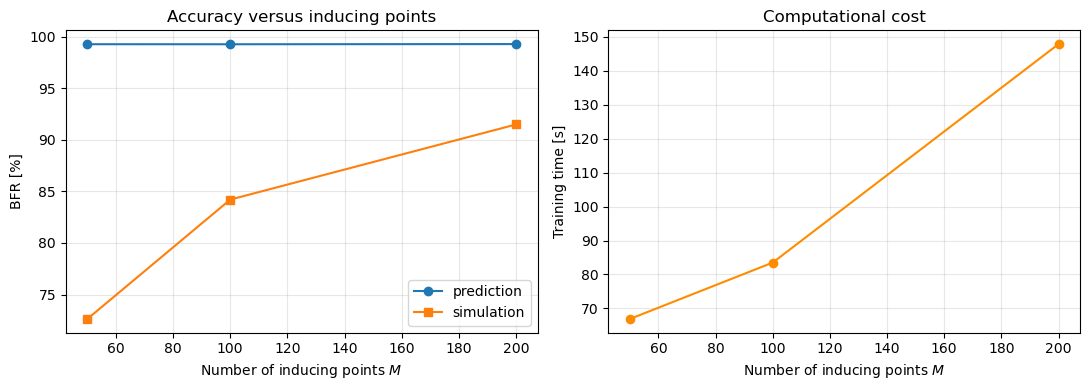

In [46]:
def simulate_sparse_for_study(model, u, th_init, na, nb, n_steps):
    start = max(na, nb)
    y_sim = th_init[:start].astype(float).tolist()
    for k in range(start, n_steps):
        x = np.array(y_sim[k-na:k] + u[k-nb:k].tolist())[None, :]
        y_next = model.predict(x)[0].ravel()[0]
        y_sim.append(float(y_next))
    return np.asarray(y_sim)

M_candidates = [50, 100, 200]
N_SPARSE_STUDY = min(6000, len(Xtrain))
N_SPARSE_SIM = min(2000, len(u_val))
SPARSE_STUDY_MAX_ITERS = 100

# All comparison models use exactly the same training subset.
study_idx = np.linspace(0, len(Xtrain) - 1, N_SPARSE_STUDY, dtype=int)
X_sparse_study = Xtrain[study_idx]
Y_sparse_study = Ytrain[study_idx, None]

# Nested initialization: the M=50 and M=100 points are contained in M=200.
rng_study = np.random.default_rng(42)
inducing_pool_idx = rng_study.choice(N_SPARSE_STUDY, max(M_candidates), replace=False)

sparse_study_models = {}
sparse_train_times = {}

for M_try in M_candidates:
    kernel_try = make_sparse_kernel(na, nb)
    Z_try = X_sparse_study[inducing_pool_idx[:M_try]].copy()

    model_try = GPy.models.SparseGPRegression(
        X_sparse_study, Y_sparse_study, Z=Z_try, kernel=kernel_try
    )
    model_try.inference_method = VarDTC()
    model_try.likelihood.variance = sigma_e2_est
    model_try.Z.unconstrain()

    t0 = time.time()
    model_try.optimize(
        'bfgs', messages=False, max_iters=SPARSE_STUDY_MAX_ITERS
    )
    sparse_train_times[M_try] = time.time() - t0
    sparse_study_models[M_try] = model_try

sparse_study_results = {}
start_sparse = max(na, nb)

for M_try in M_candidates:
    model_try = sparse_study_models[M_try]
    pred_try = model_try.predict(Xval)[0].ravel()
    sim_try = simulate_sparse_for_study(
        model_try, u_val, th_val, na, nb, N_SPARSE_SIM
    )

    sparse_study_results[M_try] = {
        "Prediction BFR [%]": BFR(Yval, pred_try),
        "Simulation BFR [%]": BFR(
            th_val[start_sparse:N_SPARSE_SIM], sim_try[start_sparse:]
        ),
        "Training time [s]": sparse_train_times[M_try],
    }

print(f"{'M':>5} {'Pred. BFR':>12} {'Sim. BFR':>12} {'Time [s]':>12}")
for M_try in M_candidates:
    result = sparse_study_results[M_try]
    print(
        f"{M_try:>5} {result['Prediction BFR [%]']:>12.2f} "
        f"{result['Simulation BFR [%]']:>12.2f} "
        f"{result['Training time [s]']:>12.1f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    M_candidates,
    [sparse_study_results[m]["Prediction BFR [%]"] for m in M_candidates],
    'o-', label='prediction'
)
axes[0].plot(
    M_candidates,
    [sparse_study_results[m]["Simulation BFR [%]"] for m in M_candidates],
    's-', label='simulation'
)
axes[0].set_xlabel("Number of inducing points $M$")
axes[0].set_ylabel("BFR [%]")
axes[0].set_title("Accuracy versus inducing points")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    M_candidates,
    [sparse_study_results[m]["Training time [s]"] for m in M_candidates],
    'o-', color='darkorange'
)
axes[1].set_xlabel("Number of inducing points $M$")
axes[1].set_ylabel("Training time [s]")
axes[1].set_title("Computational cost")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Conclusion.** Increasing the number of inducing points has almost no effect on one-step prediction, which remains near **99.26% BFR**, but it substantially improves free-run simulation. The simulation BFR increases from **72.63%** for $M=50$, to **84.20%** for $M=100$, and **91.48%** for $M=200$. Training time increases from **61.7 s** to **144.9 s**. The model with $M=200$ is selected because the simulation improvement is substantial and the training cost remains practical.

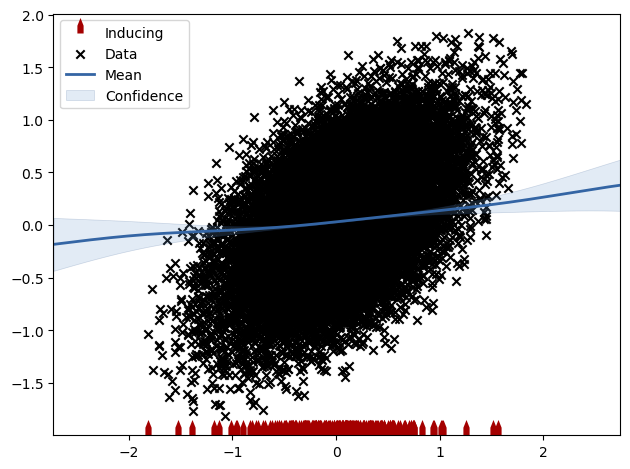

In [47]:
fixed_inputs = [(i, float(Xtrain[:, i].mean())) for i in range(1, na+nb)]
m_sparse.plot(visible_dims=[0], fixed_inputs=fixed_inputs)
plt.show()

## 6. One-step validation prediction

For one-step prediction, the model receives measured past angles and voltage inputs. This evaluates how accurately it predicts the next sample when the regressor contains the true recent history, so errors do not accumulate over time.

The measured angle is compared with the GP mean and its $\pm2\sigma$ uncertainty interval. The residual $e_k=\theta_k-\hat\theta_k$ is plotted separately to reveal periods where the model is systematically inaccurate. BFR, RMSE, NRMS, and the percentage of measurements inside the uncertainty interval summarize prediction accuracy and uncertainty calibration.

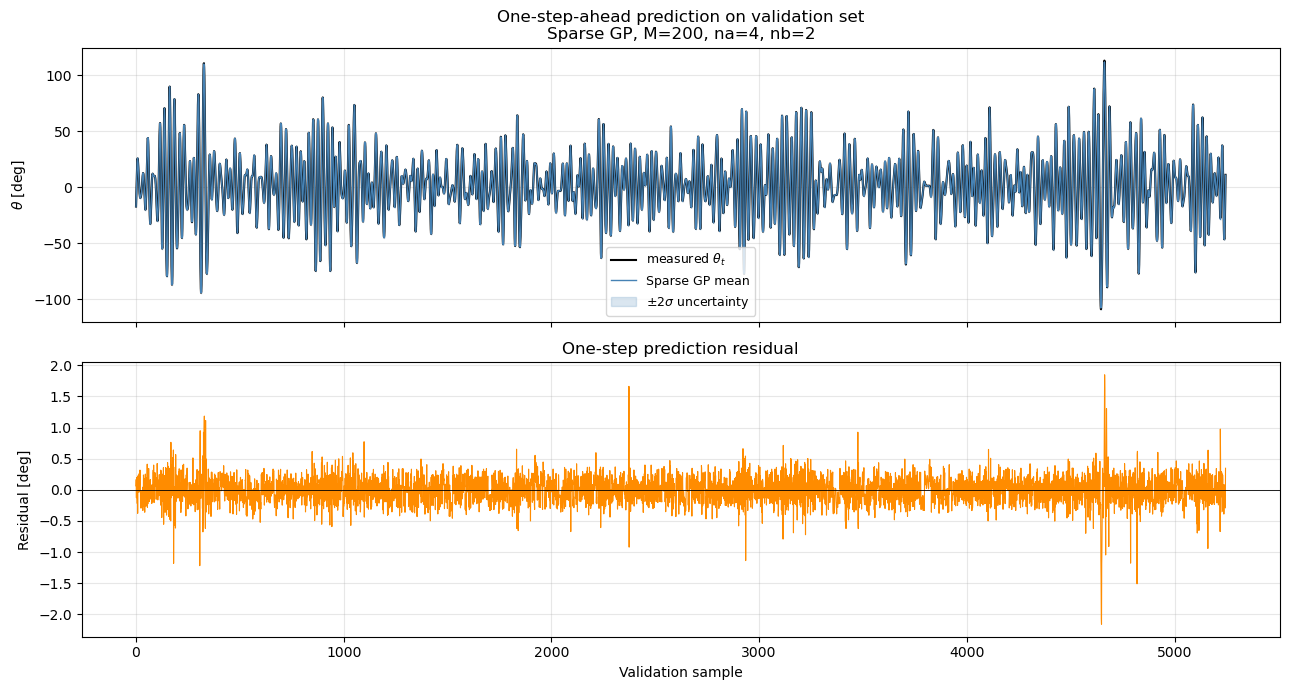

Prediction BFR on validation:  99.2%
Prediction RMSE on validation: 0.00376 rad
Prediction RMSE on validation: 0.215 deg
Prediction NRMS on validation: 0.76%
Samples inside ±2σ interval: 97.3%


In [48]:
# -----------------------------
# One-step-ahead prediction plot
# -----------------------------

N_plot = th_val.shape[0]  # number of validation samples to visualize

# Make sure we do not ask for more samples than available
N_plot = min(N_plot, Xval.shape[0])

# GPy returns predictive mean and predictive variance
Ypred_plot, Yvar_plot = m_sparse.predict(Xval[:N_plot])

# Convert from shape (N, 1) to shape (N,)
Ypred_plot = Ypred_plot.flatten()
Ystd_plot = np.sqrt(Yvar_plot).flatten()
Ytrue_plot = Yval[:N_plot].flatten()

# Prediction and residual plots.
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(
    np.degrees(Ytrue_plot),
    "k",
    lw=1.5,
    label="measured $\\theta_t$"
)
axes[0].plot(
    np.degrees(Ypred_plot),
    color="steelblue",
    lw=1.0,
    label="Sparse GP mean"
)
axes[0].fill_between(
    np.arange(N_plot),
    np.degrees(Ypred_plot - 2 * Ystd_plot),
    np.degrees(Ypred_plot + 2 * Ystd_plot),
    color="steelblue",
    alpha=0.2,
    label="$\\pm2\\sigma$ uncertainty"
)
axes[0].set_ylabel("$\\theta$ [deg]")
axes[0].set_title(
    f"One-step-ahead prediction on validation set\n"
    f"Sparse GP, M={M}, na={na}, nb={nb}"
)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

prediction_residual = Ytrue_plot - Ypred_plot
axes[1].plot(np.degrees(prediction_residual), color="darkorange", lw=0.8)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("Validation sample")
axes[1].set_ylabel("Residual [deg]")
axes[1].set_title("One-step prediction residual")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Metrics
# -----------------------------

val_prediction_bfr = BFR(Ytrue_plot, Ypred_plot)
val_prediction_rmse = RMSE(Ytrue_plot, Ypred_plot)
val_prediction_nrms = val_prediction_rmse / Ytrue_plot.std() * 100

print(f"Prediction BFR on validation:  {val_prediction_bfr:.1f}%")
print(f"Prediction RMSE on validation: {val_prediction_rmse:.5f} rad")
print(f"Prediction RMSE on validation: {np.degrees(val_prediction_rmse):.3f} deg")
print(f"Prediction NRMS on validation: {val_prediction_nrms:.2f}%")
coverage_2sigma = np.mean(np.abs(prediction_residual) <= 2 * Ystd_plot) * 100
print(f"Samples inside ±2σ interval: {coverage_2sigma:.1f}%")

**Conclusion.** The final sparse GP reaches a one-step validation BFR of **99.24%**, with an RMSE of **0.215°** and an NRMS of **0.76%**. The $\pm2\sigma$ interval contains **97.3%** of the measurements, which is close to the expected 95% coverage and indicates slightly conservative but well-calibrated uncertainty.

## 7. Free-run validation simulation

One-step prediction does not fully test a dynamic model because measured angles are supplied at every step. In free-run simulation, only the initial measured angles are used. Each predicted angle is then fed back into the NARX regressor, allowing errors to accumulate as they would in a standalone simulation.

The simulated trajectory and residual show whether the model follows the long-term motion of the disk without drifting. Simulation BFR, RMSE, and NRMS therefore provide the main evidence that the GP has captured the system dynamics rather than only the short-term correlation of the measured angle.

Simulation BFR:  87.9%
Simulation RMSE: 0.0593 rad  (3.40°)
Simulation NRMS: 12.05%


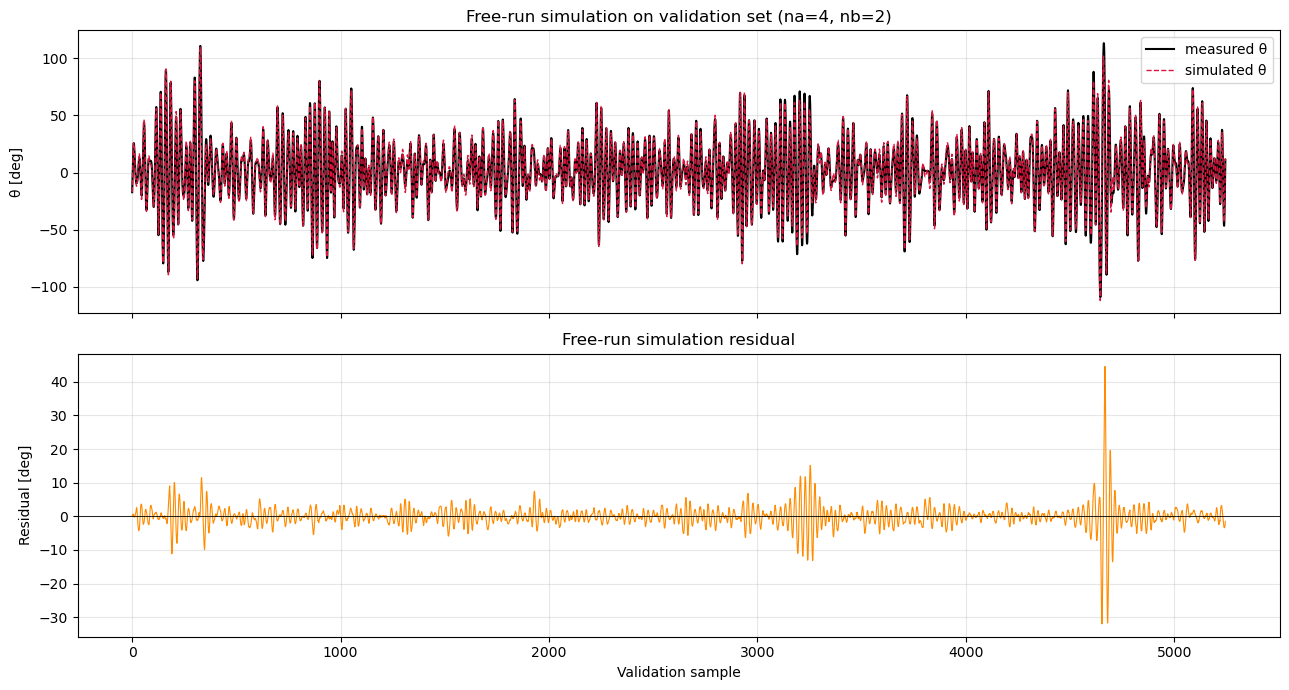

In [49]:
def simulate(model, u, th_init, na, nb, skip=None):
    """
    Free-run simulation. Returns array of same length as u.
    First `skip` values are copied from th_init (warm-up).
    After that, predicted angles are fed back.
    """
    if skip is None:
        skip = max(na, nb)   # minimum needed for feature construction
 
    # Initialise sliding windows from real data
    thpast = th_init[skip-na : skip].tolist()   # [th(skip-na), ..., th(skip-1)]
    upast  = u[skip-nb      : skip].tolist()    # [u(skip-nb),  ..., u(skip-1)]
 
    Y = th_init[:skip].tolist()   # pre-fill warm-up with real values
 
    for k in range(skip, len(u)):
        x = np.array(thpast + upast)            # same order as make_training_data
        ypred = model.predict(x[None,:])[0].flatten()[0]
        Y.append(ypred)
        thpast.append(ypred);  thpast.pop(0)    # slide theta window
        upast.append(u[k]);    upast.pop(0)     # slide u window
 
    return np.array(Y)   # always len(u) samples

start = max(na, nb)

th_sim  = simulate(m_sparse, u_val, th_val, na=na, nb=nb)
th_true = th_val[start:]

val_simulation_bfr = BFR(th_true, th_sim[start:])
val_simulation_rmse = RMSE(th_true, th_sim[start:])
val_simulation_nrms = val_simulation_rmse / th_true.std() * 100

print(f"Simulation BFR:  {val_simulation_bfr:.1f}%")
print(f"Simulation RMSE: {val_simulation_rmse:.4f} rad  ({np.degrees(val_simulation_rmse):.2f}°)")
print(f"Simulation NRMS: {val_simulation_nrms:.2f}%")

simulation_residual = th_true - th_sim[start:]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(np.degrees(th_true), 'k', lw=1.5, label='measured θ')
axes[0].plot(np.degrees(th_sim[start:]), color='crimson', ls='--', lw=1, label='simulated θ')
axes[0].set_ylabel("θ [deg]")
axes[0].set_title(f"Free-run simulation on validation set (na={na}, nb={nb})")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.degrees(simulation_residual), color='darkorange', lw=0.8)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel("Validation sample")
axes[1].set_ylabel("Residual [deg]")
axes[1].set_title("Free-run simulation residual")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusion.** In free-run validation, the model obtains a BFR of **87.95%**, an RMSE of **3.399°**, and an NRMS of **12.05%**. The reduction relative to one-step prediction is expected because every predicted angle is fed back into the model. The trajectory remains stable, but accumulated feedback errors are the main limitation of the model.

### Interpretation of the learned dynamics

The high one-step prediction score is partly caused by the strong relation between consecutive angle measurements. To inspect what the GP learned beyond $\theta_k\approx\theta_{k-1}$, the angle increment

$$\Delta\theta_k=\theta_k-\theta_{k-1}$$

is examined as a function of the latest angle and voltage input. The left panel shows measured increments. The right panel shows the increment predicted by the final GP while the remaining regressors are fixed at their training-set means. This is an interpretation plot rather than a separate performance measure.

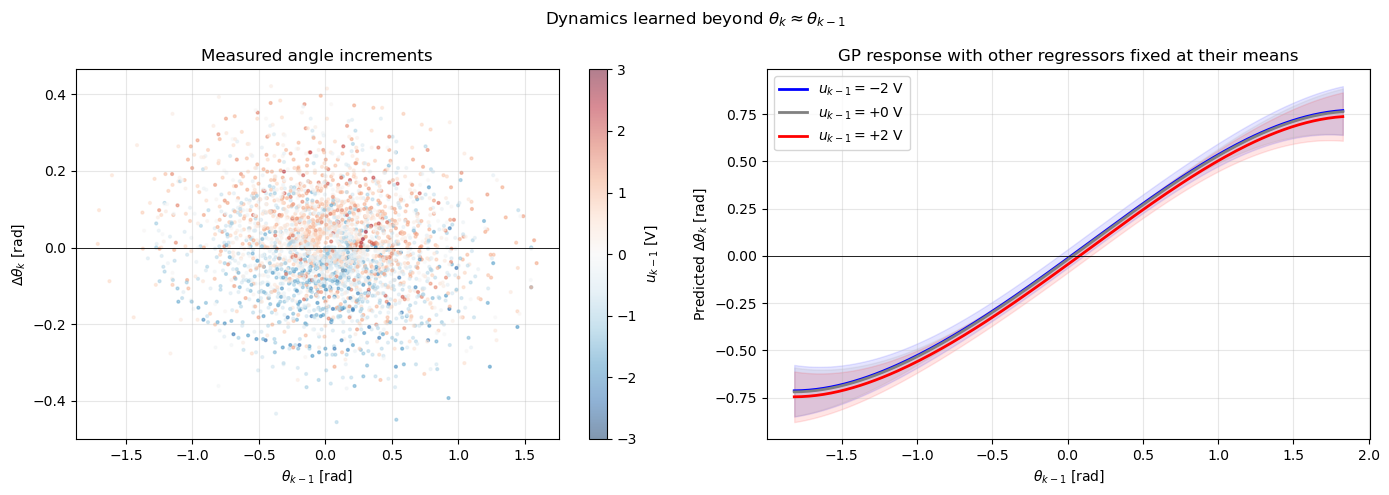

In [50]:
# Latest angle and voltage locations in the NARX regressor.
theta_latest_idx = na - 1
u_latest_idx = na + nb - 1

delta_theta_train = Ytrain - Xtrain[:, theta_latest_idx]
N_INTERPRET = min(3000, len(Xtrain))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(
    Xtrain[:N_INTERPRET, theta_latest_idx],
    delta_theta_train[:N_INTERPRET],
    c=Xtrain[:N_INTERPRET, u_latest_idx],
    cmap='RdBu_r',
    s=4,
    alpha=0.5,
    vmin=-3,
    vmax=3,
)
plt.colorbar(scatter, ax=axes[0], label='$u_{k-1}$ [V]')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_xlabel('$\\theta_{k-1}$ [rad]')
axes[0].set_ylabel('$\\Delta\\theta_k$ [rad]')
axes[0].set_title('Measured angle increments')
axes[0].grid(alpha=0.3)

theta_grid = np.linspace(
    Xtrain[:, theta_latest_idx].min(),
    Xtrain[:, theta_latest_idx].max(),
    150,
)
x_reference = Xtrain.mean(axis=0)

for voltage, color in zip([-2.0, 0.0, 2.0], ['blue', 'gray', 'red']):
    X_line = np.tile(x_reference, (len(theta_grid), 1))
    X_line[:, theta_latest_idx] = theta_grid
    X_line[:, u_latest_idx] = voltage

    mean_line, var_line = m_sparse.predict(X_line)
    mean_line = mean_line.ravel()
    std_line = np.sqrt(var_line).ravel()
    delta_mean = mean_line - theta_grid

    axes[1].plot(
        theta_grid, delta_mean, color=color, lw=2,
        label=f'$u_{{k-1}}={voltage:+.0f}$ V'
    )
    axes[1].fill_between(
        theta_grid,
        delta_mean - 2 * std_line,
        delta_mean + 2 * std_line,
        color=color,
        alpha=0.1,
    )

axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel('$\\theta_{k-1}$ [rad]')
axes[1].set_ylabel('Predicted $\\Delta\\theta_k$ [rad]')
axes[1].set_title('GP response with other regressors fixed at their means')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Dynamics learned beyond $\\theta_k \\approx \\theta_{k-1}$')
plt.tight_layout()
plt.show()

## 8. Held-out test evaluation

All model choices are made using the training and validation sections. The final sparse GP is then evaluated once on the held-out test section, which has not been used for model selection.

Both one-step prediction and free-run simulation are reported. Agreement between validation and test performance indicates that the selected model generalizes to a separate part of the experiment.

Test prediction BFR:  99.13%
Test prediction RMSE: 0.258 deg
Test prediction NRMS: 0.87%
Test simulation BFR:  85.50%
Test simulation RMSE: 4.300 deg
Test simulation NRMS: 14.50%


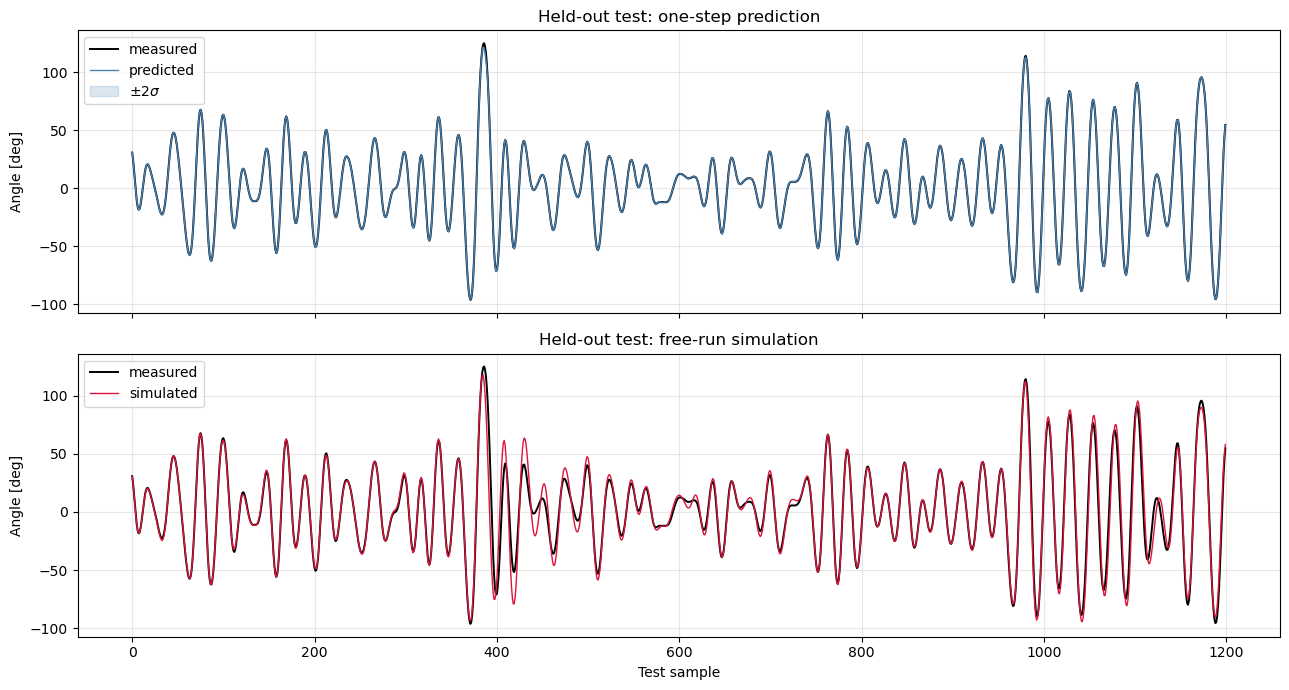

In [51]:
Xtest_eval, Ytest_eval = make_training_data(u_test, th_test, na, nb)

# One-step prediction on the held-out test section.
Ypred_test, Yvar_test = m_sparse.predict(Xtest_eval)
Ypred_test = Ypred_test.ravel()
Ystd_test = np.sqrt(Yvar_test).ravel()

test_prediction_bfr = BFR(Ytest_eval, Ypred_test)
test_prediction_rmse = RMSE(Ytest_eval, Ypred_test)
test_prediction_nrms = test_prediction_rmse / Ytest_eval.std() * 100

# Free-run simulation on the held-out test section.
test_start = max(na, nb)
th_sim_test_eval = simulate(m_sparse, u_test, th_test, na=na, nb=nb)
test_sim_true = th_test[test_start:]
test_sim_pred = th_sim_test_eval[test_start:]
test_simulation_bfr = BFR(test_sim_true, test_sim_pred)
test_simulation_rmse = RMSE(test_sim_true, test_sim_pred)
test_simulation_nrms = test_simulation_rmse / test_sim_true.std() * 100

print(f"Test prediction BFR:  {test_prediction_bfr:.2f}%")
print(f"Test prediction RMSE: {np.degrees(test_prediction_rmse):.3f} deg")
print(f"Test prediction NRMS: {test_prediction_nrms:.2f}%")
print(f"Test simulation BFR:  {test_simulation_bfr:.2f}%")
print(f"Test simulation RMSE: {np.degrees(test_simulation_rmse):.3f} deg")
print(f"Test simulation NRMS: {test_simulation_nrms:.2f}%")

N_TEST_PLOT = min(1200, len(Ytest_eval), len(test_sim_true))
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(np.degrees(Ytest_eval[:N_TEST_PLOT]), 'k', lw=1.4, label='measured')
axes[0].plot(np.degrees(Ypred_test[:N_TEST_PLOT]), color='steelblue', lw=1, label='predicted')
axes[0].fill_between(
    np.arange(N_TEST_PLOT),
    np.degrees(Ypred_test[:N_TEST_PLOT] - 2 * Ystd_test[:N_TEST_PLOT]),
    np.degrees(Ypred_test[:N_TEST_PLOT] + 2 * Ystd_test[:N_TEST_PLOT]),
    color='steelblue', alpha=0.2, label='$\\pm2\\sigma$'
)
axes[0].set_ylabel('Angle [deg]')
axes[0].set_title('Held-out test: one-step prediction')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.degrees(test_sim_true[:N_TEST_PLOT]), 'k', lw=1.4, label='measured')
axes[1].plot(np.degrees(test_sim_pred[:N_TEST_PLOT]), color='crimson', lw=1, label='simulated')
axes[1].set_xlabel('Test sample')
axes[1].set_ylabel('Angle [deg]')
axes[1].set_title('Held-out test: free-run simulation')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion.** On the held-out test data, the model reaches **99.13%** prediction BFR and **85.50%** simulation BFR. The corresponding RMSE values are **0.258°** and **4.300°**. Compared with validation, prediction decreases by only **0.11 percentage points** and simulation by **2.45 percentage points**. This is a modest generalization gap and does not indicate a clear overfitting problem.

## 9. Final performance summary

The final model is summarized using the same measures for validation and test data. Prediction assesses local one-step accuracy, while simulation assesses the accumulated dynamic behavior.

| Dataset | Task | BFR [%] | RMSE [deg] | NRMS [%] |
|---|---|---:|---:|---:|
| Validation | Prediction | 99.24 | 0.215 | 0.76 |
| Validation | Simulation | 87.95 | 3.399 | 12.05 |
| Test | Prediction | 99.13 | 0.258 | 0.87 |
| Test | Simulation | 85.50 | 4.300 | 14.50 |

## Final conclusion

The selected model is a sparse GP-NARX model with $n_a=4$, $n_b=2$, and $M=200$ inducing points. The angle component of the kernel combines periodic and smooth behavior, while the voltage component is modeled separately with an RBF kernel.

The model achieves **99.24%** prediction BFR and **87.95%** simulation BFR on validation data. On the held-out test data, the corresponding results are **99.13%** and **85.50%**. The test simulation score is only **2.45 percentage points** below validation, so there is no clear evidence of severe overfitting. The main remaining limitation is the accumulation of small errors during free-run simulation, which increases the test simulation RMSE to **4.300°**.

## 10. Hidden-test submission files

The final two cells apply the selected sparse GP to the hidden benchmark data. The first file contains one-step predictions and the second contains a free-run simulation.

After the final model has been trained, the following files are generated:

- `gp-prediction-submission.npz`
- `gp-simulation-submission.npz`

The benchmark input arrays and specified output names are preserved in both files.

In [52]:
### Prepare submission file for hidden test set prediction
rel_path = 'gym-unbalanced-disk-master/disc-benchmark-files/'
pred_data = np.load(rel_path+'hidden-test-prediction-submission-file.npz')
u_test = pred_data['upast']  # shape (N_test,)
th_test = pred_data['thpast']  # shape (N_test,)

x_test = np.concatenate([th_test[:,15-na:], u_test[:,15-nb:]], axis=1)
Ypred, Ystd = m_sparse.predict(x_test)
th_now_test = Ypred.flatten()

np.savez('my-prediction-submission.npz', upast=u_test, thpast=th_test, thnow=th_now_test)

In [ ]:
### Prepare submission file for hidden test set simulation
rel_path = 'gym-unbalanced-disk-master/disc-benchmark-files/'
sim_data = np.load(rel_path+'hidden-test-simulation-submission-file.npz')
u_test = sim_data['u']  # shape (N_test,)
th_test = sim_data['th']  # shape (N_test,)
th_submission = th_test.copy()

th_sim_test = simulate(m_sparse, u_test, th_test, na=na, nb=nb)
th_submission[50:] = th_sim_test[50:]
np.savez('my-simulation-submission.npz', u=u_test, th=th_submission)